Import

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns

Reading Files

In [2]:
essays = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/essays.csv')
outcomes = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/outcomes.csv')
projects = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/projects.csv')
donations = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/donations.csv')

Merging

In [3]:
combined = projects.merge(outcomes,how='inner',on='projectid').merge(essays,how='inner',on='projectid')

In [4]:
combined.isna().sum()

projectid                                              0
teacher_acctid_x                                       0
schoolid                                               0
school_ncesid                                      38848
school_latitude                                        0
school_longitude                                       0
school_city                                            0
school_state                                           0
school_zip                                             4
school_metro                                       75488
school_district                                      922
school_county                                         17
school_charter                                         0
school_magnet                                          0
school_year_round                                      0
school_nlns                                            0
school_kipp                                            0
school_charter_ready_promise   

Preparing the Data

In [5]:
#dropping columns that are not important such as teacher account id
#dropping columns with too many categories such as school city

columns = ['projectid','school_state','school_metro','school_magnet','school_nlns',
           'school_kipp','school_charter_ready_promise','teacher_teach_for_america',
           'teacher_ny_teaching_fellow','primary_focus_subject','primary_focus_area',
           'resource_type','poverty_level','grade_level','total_price_excluding_optional_support',
           'total_price_including_optional_support','students_reached','eligible_double_your_impact_match',
           'eligible_almost_home_match','date_posted','fully_funded','short_description','need_statement','essay']

data = combined[columns]

In [6]:
#convert t/f values to binary for relevant categorical data

columns_binary = ['school_magnet','school_nlns',
           'school_kipp','school_charter_ready_promise','teacher_teach_for_america',
           'teacher_ny_teaching_fellow','eligible_double_your_impact_match',
           'eligible_almost_home_match','fully_funded']

binary_map = {'f':0,'t':1}

for col in columns_binary:
    data.loc[:,col] = data[col].map(binary_map)

data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,...,total_price_excluding_optional_support,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay
0,62526d85d2a1818432d03d600969e99c,IL,suburban,0,0,0,0,0,0,Special Needs,...,444.36,522.78,7.0,0,0,2013-12-31,1,"If they can't learn the way we teach, we teach...","My students need puzzles, games and visual lea...","If they can't learn the way we teach, we teach..."
1,33d59ac771b80222ad63ef0f4ac47ade,ID,urban,0,0,0,0,0,0,Mathematics,...,233.24,274.40,30.0,0,0,2013-12-31,0,"Which is bigger, three liters or three quarts?...",My students need capacity tools and resources ...,"Which is bigger, three liters or three quarts?..."
2,1a3aaeffc56dd2a421e37d8298024c0a,NH,suburban,0,0,0,0,0,0,Environmental Science,...,285.09,335.40,230.0,0,0,2013-12-31,0,Do you remember classrooms that used just book...,My students need UV sensitive beads and a Vern...,Do you remember classrooms that used just book...
3,33aa19ee4da4c5adf47d0dfb84fab5ef,VA,urban,0,0,0,0,0,0,Literacy,...,232.94,274.05,18.0,0,0,2013-12-31,0,My class was given the beautiful gift of books...,My students need labels and book bins to organ...,My class was given the beautiful gift of books...
4,e31c0ea8b68f404699dfb0d39e9bc99b,IL,urban,1,0,0,0,0,0,Environmental Science,...,513.41,604.01,70.0,1,0,2013-12-31,1,Thinking back in school science was either rea...,My students need an Interactive whiteboard les...,Thinking back in school science was either rea...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619321,a7236ea96c812895cafc5d700d779147,NY,urban,0,0,0,0,0,0,Environmental Science,...,231.00,281.71,0.0,0,0,2002-09-17,1,My name is Mary Reide. I am a New York City T...,"The cost of this proposal is [price], includin...",My name is Mary Reide. I am a New York City T...
619322,e02da37beb332eb66c2d2ba989c597ad,NY,urban,0,0,0,0,0,0,Economics,...,1129.00,1376.83,0.0,0,0,2002-09-17,1,I teach economics to 25 students at Satellite ...,"The cost of this proposal is $1377, including ...",I teach economics to 25 students at Satellite ...
619323,82e536f14eadf2671a70e03416f695a3,NY,urban,1,0,0,0,0,0,Early Development,...,125.00,152.44,0.0,0,0,2002-09-16,1,I just returned from 3 weeks in S. Africa. I w...,"The cost of this proposal is [price], includin...",I just returned from 3 weeks in S. Africa. I ...
619324,e139df754a873a62d93daa56acbf8040,NY,NaN,0,0,0,0,0,0,Literacy,...,125.00,152.44,0.0,0,0,2002-09-13,1,I teach 9th grade Humanities at Vanguard High ...,"The cost of this proposal is [price], includin...",I teach 9th grade Humanities at Vanguard High ...


Normalizing to Address Outlier Issues

In [7]:
data['students_reached'].describe()

count    619182.000000
mean         97.439624
std        2364.069969
min           0.000000
25%          22.000000
50%          30.000000
75%         100.000000
max      999999.000000
Name: students_reached, dtype: float64

C:\Users\yzhen\AppData\Local\Temp\ipykernel_5524\892991641.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['students_reached_scaled'] = scaler.fit_transform(data.loc[:,['students_reached']])


<Axes: xlabel='students_reached_scaled', ylabel='Count'>

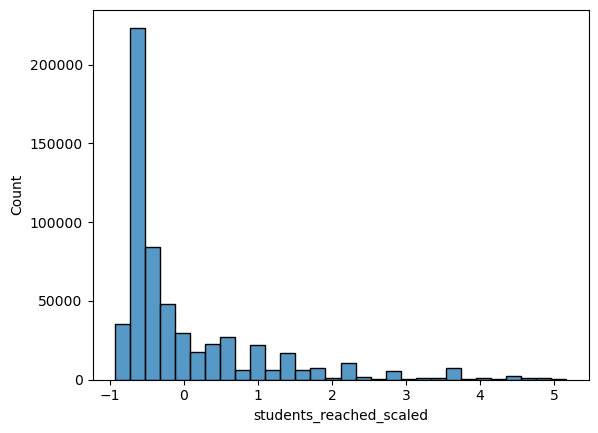

In [8]:
q = data['students_reached'].quantile(0.95)

scaler = StandardScaler()
data = data[data['students_reached'] < q]
data['students_reached_scaled'] = scaler.fit_transform(data.loc[:,['students_reached']])

sns.histplot(data['students_reached_scaled'],bins=30, kde=False)


In [9]:
q = data['total_price_excluding_optional_support'].describe()

<Axes: xlabel='total_price_excluding_optional_support_scaled', ylabel='Count'>

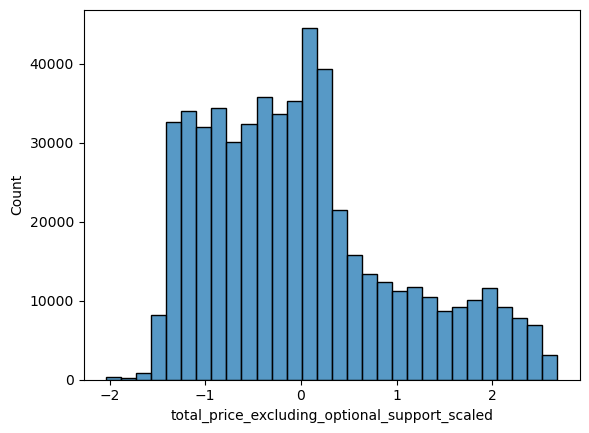

In [10]:
q = data['total_price_excluding_optional_support'].quantile(0.95)

data = data[data['total_price_excluding_optional_support'] < q]
data['total_price_excluding_optional_support_scaled'] = scaler.fit_transform(data.loc[:,['total_price_excluding_optional_support']])

sns.histplot(data['total_price_excluding_optional_support_scaled'],bins=30, kde=False)

In [11]:
# #dropping outliers for requested funds

# q1 = data['total_price_excluding_optional_support'].quantile(0.25)
# q3 = data['total_price_excluding_optional_support'].quantile(0.75)
# iqr = q3 - q1

# lower_bound = q1 - 0.75 * iqr
# upper_bound = q3 + 5.5 * iqr

# # checking how much is being droppped 
# # (data['total_price_excluding_optional_support'] > upper_bound).sum()
# # (data['total_price_excluding_optional_support'] < lower_bound).sum()

# data = data[(data['total_price_excluding_optional_support'] >= lower_bound)]
# data = data[(data['total_price_excluding_optional_support'] <= upper_bound)]

# print(
# data['total_price_excluding_optional_support'].describe(),'\n',
# data['total_price_excluding_optional_support'].skew() #decreased from before cleaning
# )

In [12]:
# #dropping outliers for students

# q1 = data['students_reached'].quantile(0.25)
# q3 = data['students_reached'].quantile(0.75)
# iqr = q3 - q1

# lower_bound = q1 - 0.05 * iqr
# upper_bound = q3 + 21.5 * iqr

# print(lower_bound,upper_bound)

# # (data['total_price_excluding_optional_support'] < lower_bound).sum()
# # (data['total_price_excluding_optional_support'] > upper_bound).sum()

# data = data[(data['students_reached'] >= lower_bound)]
# data = data[(data['students_reached'] <= upper_bound)]

# print(
# data['students_reached'].describe(),'\n',
# data['students_reached'].skew() #decreased from before cleaning
# )

Mapping State to Regions

In [13]:
state_to_region = {
    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    
    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    
    # South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    
    # West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West',
    'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

In [14]:
data['school_state_region'] = data['school_state'].map(state_to_region)

In [15]:
data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,...,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,students_reached_scaled,total_price_excluding_optional_support_scaled,school_state_region
0,62526d85d2a1818432d03d600969e99c,IL,suburban,0,0,0,0,0,0,Special Needs,...,0,0,2013-12-31,1,"If they can't learn the way we teach, we teach...","My students need puzzles, games and visual lea...","If they can't learn the way we teach, we teach...",-0.818367,0.111396,Midwest
1,33d59ac771b80222ad63ef0f4ac47ade,ID,urban,0,0,0,0,0,0,Mathematics,...,0,0,2013-12-31,0,"Which is bigger, three liters or three quarts?...",My students need capacity tools and resources ...,"Which is bigger, three liters or three quarts?...",-0.467795,-0.908168,West
2,1a3aaeffc56dd2a421e37d8298024c0a,NH,suburban,0,0,0,0,0,0,Environmental Science,...,0,0,2013-12-31,0,Do you remember classrooms that used just book...,My students need UV sensitive beads and a Vern...,Do you remember classrooms that used just book...,2.580653,-0.657769,Northeast
3,33aa19ee4da4c5adf47d0dfb84fab5ef,VA,urban,0,0,0,0,0,0,Literacy,...,0,0,2013-12-31,0,My class was given the beautiful gift of books...,My students need labels and book bins to organ...,My class was given the beautiful gift of books...,-0.650702,-0.909617,South
4,e31c0ea8b68f404699dfb0d39e9bc99b,IL,urban,1,0,0,0,0,0,Environmental Science,...,1,0,2013-12-31,1,Thinking back in school science was either rea...,My students need an Interactive whiteboard les...,Thinking back in school science was either rea...,0.141894,0.444860,Midwest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619320,1c8fe14031d38a86d43f7dd09955279b,NY,urban,0,0,0,0,0,0,Literacy,...,0,0,2002-09-17,1,NaN,"Native Language novels such as ""El jardin secr...",I am a 5th/6th grade bilingual teacher at I.S....,-0.925063,-0.692008,Northeast
619321,a7236ea96c812895cafc5d700d779147,NY,urban,0,0,0,0,0,0,Environmental Science,...,0,0,2002-09-17,1,My name is Mary Reide. I am a New York City T...,"The cost of this proposal is [price], includin...",My name is Mary Reide. I am a New York City T...,-0.925063,-0.918986,Northeast
619323,82e536f14eadf2671a70e03416f695a3,NY,urban,1,0,0,0,0,0,Early Development,...,0,0,2002-09-16,1,I just returned from 3 weeks in S. Africa. I w...,"The cost of this proposal is [price], includin...",I just returned from 3 weeks in S. Africa. I ...,-0.925063,-1.430893,Northeast
619324,e139df754a873a62d93daa56acbf8040,NY,NaN,0,0,0,0,0,0,Literacy,...,0,0,2002-09-13,1,I teach 9th grade Humanities at Vanguard High ...,"The cost of this proposal is [price], includin...",I teach 9th grade Humanities at Vanguard High ...,-0.925063,-1.430893,Northeast


Dropping Null

In [16]:
#sort ascending chronologically

data = data.sort_values(by='date_posted')

#drop missing value

percent_loss = round((data.shape[0] - data.dropna().shape[0])/data.shape[0],4)

print(f'{percent_loss*100}%')

12.55%


In [17]:
data.dropna(inplace=True)
data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,...,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,students_reached_scaled,total_price_excluding_optional_support_scaled,school_state_region
619325,77558a6eda151deee9a00553f7fccfc7,NY,urban,1,0,0,0,0,0,Other,...,0,0,2002-09-13,1,I am a first year teacher assigned to the 6th ...,"The cost of this proposal is [price], includin...",I am a first year teacher assigned to the 6th ...,-0.925063,-0.928645,Northeast
619323,82e536f14eadf2671a70e03416f695a3,NY,urban,1,0,0,0,0,0,Early Development,...,0,0,2002-09-16,1,I just returned from 3 weeks in S. Africa. I w...,"The cost of this proposal is [price], includin...",I just returned from 3 weeks in S. Africa. I ...,-0.925063,-1.430893,Northeast
619321,a7236ea96c812895cafc5d700d779147,NY,urban,0,0,0,0,0,0,Environmental Science,...,0,0,2002-09-17,1,My name is Mary Reide. I am a New York City T...,"The cost of this proposal is [price], includin...",My name is Mary Reide. I am a New York City T...,-0.925063,-0.918986,Northeast
619295,c7d251ab36c83155af3269afc8df0b63,NY,urban,0,0,0,0,0,0,Literacy,...,0,0,2002-09-17,1,Hello! I am a fifth and sixth grade bilingual ...,"The cost of the books, ranging from ""El Castil...",Hello! I am a fifth and sixth grade bilingual ...,-0.925063,-0.784973,Northeast
619298,fd5a8eccdbaa72f9d526dd6e97ca063d,NY,urban,0,0,0,0,1,0,Early Development,...,0,0,2002-09-17,1,"Hi, my name is Sara Shenkan and I am a 4th gra...","The cost of this proposal is $476, including s...","Hi, my name is Sara Shenkan and I am a 4th gra...",-0.925063,-0.151126,Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,f820ef3537f4445b0716244fae36f763,ID,urban,0,0,0,0,0,0,Mathematics,...,0,0,2013-12-31,0,Math and reading are two separate subjects in ...,My students need a large range of math stories...,Math and reading are two separate subjects in ...,-0.467795,-0.695051,West
131,95ee208a51831edffa7cc2e0aa3e83cd,AZ,urban,0,0,0,0,0,0,Literacy,...,0,0,2013-12-31,1,Remember the first book you ever loved? How yo...,My students need books to improve their readin...,Remember the first book you ever loved? How yo...,0.568677,-1.057394,West
130,383500f017fea60562ba737b051e1d21,MN,suburban,0,0,0,0,0,0,Literature & Writing,...,0,0,2013-12-31,1,"I will be honest with you, I'm horrible at pre...",My students need funding for a workshop at The...,"I will be honest with you, I'm horrible at pre...",-0.483038,0.561198,Midwest
151,12eaae86b748362dfad4e68b2c5508a2,AZ,rural,0,0,0,0,0,0,Mathematics,...,0,0,2013-12-31,0,My class absolutely loves math. It is their fa...,"My students need Math resources, for new Math ...",My class absolutely loves math. It is their fa...,0.904006,-1.127564,West


EDA

In [24]:
data[['total_price_excluding_optional_support','students_reached','fully_funded']].groupby('fully_funded').describe()

total_price_excluding_optional_support                          \
                                              count        mean         std   
fully_funded                                                                  
0                                          138720.0  572.529243  331.602523   
1                                          331017.0  430.800017  274.709238   

                                                     students_reached  \
                min    25%      50%     75%      max            count   
fully_funded                                                            
0             38.00  361.0  475.925  725.74  2240.67         138720.0   
1             37.92  241.9  378.150  510.77  2240.70         331017.0   

                                                                       
                    mean         std   min   25%   50%    75%     max  
fully_funded                                                           
0             105.787197  162.181586  19.0  25.0  40.0  110.0  1663.0  
1              98.393279  150.723566  19.0  25.0  40.0  100.0  1600.0